In [24]:
import os
import pandas as pd
import numpy as np
# from scipy.integrate import cumulative_trapezoid
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm  
import seaborn as sns
import numpy as np
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist
from tqdm.auto import tqdm

In [25]:
base_path = 'all_battery_data_with_EIS_params.csv'
all_battery_data_EIS = pd.read_csv(base_path)

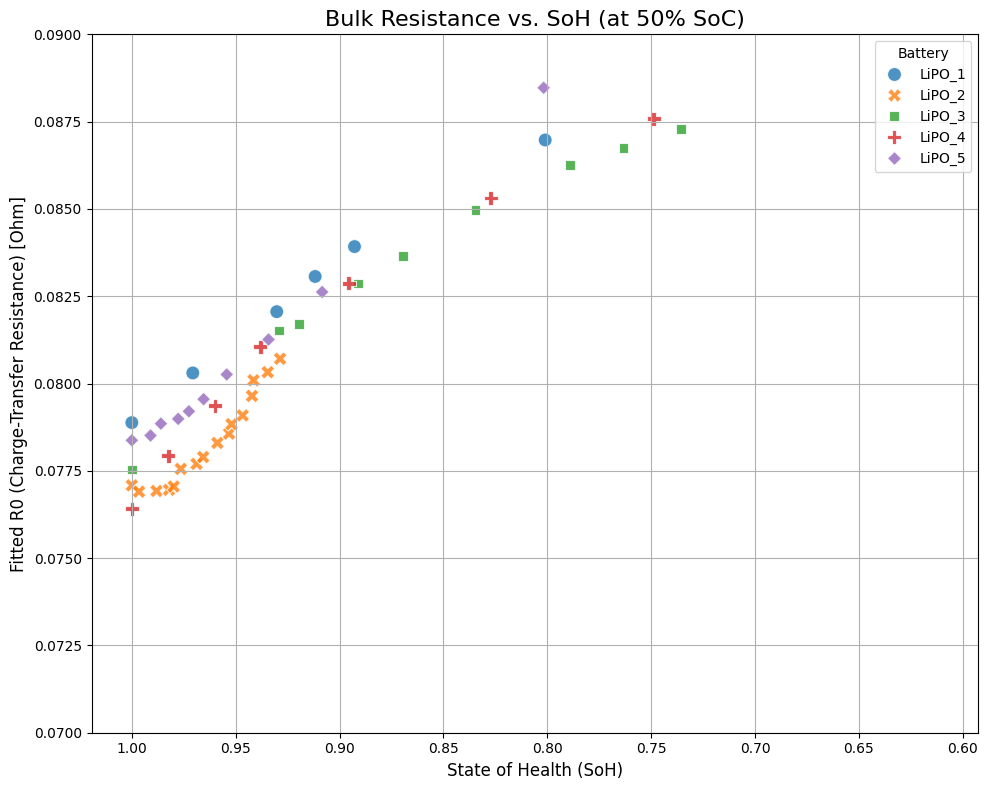

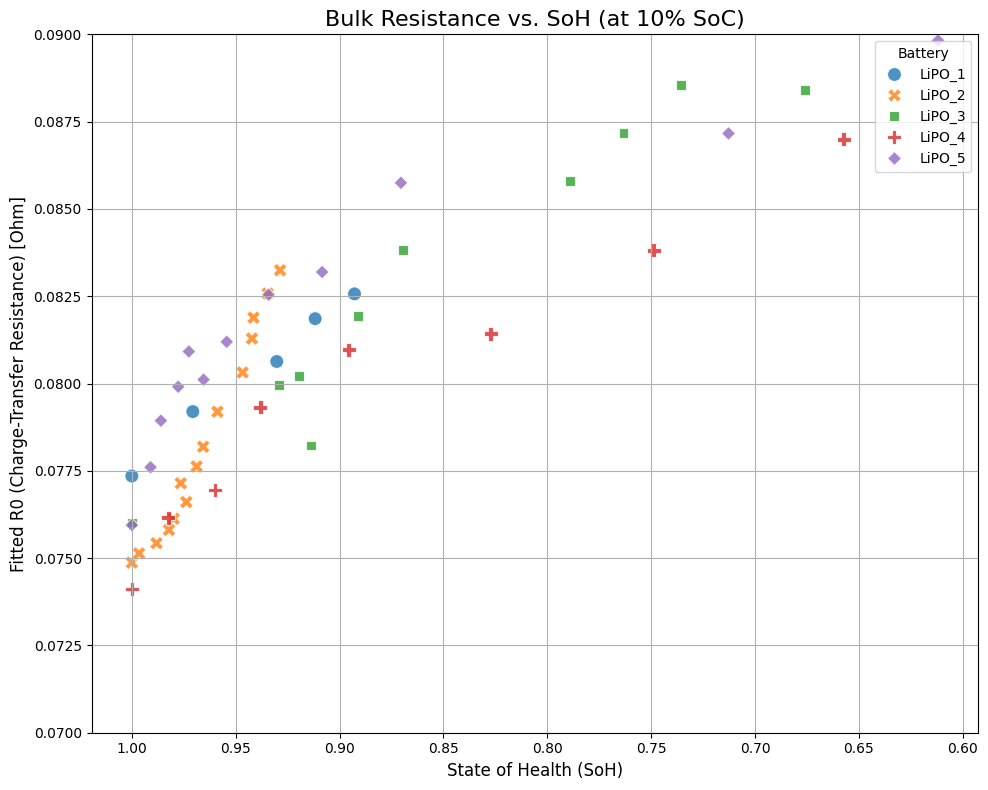

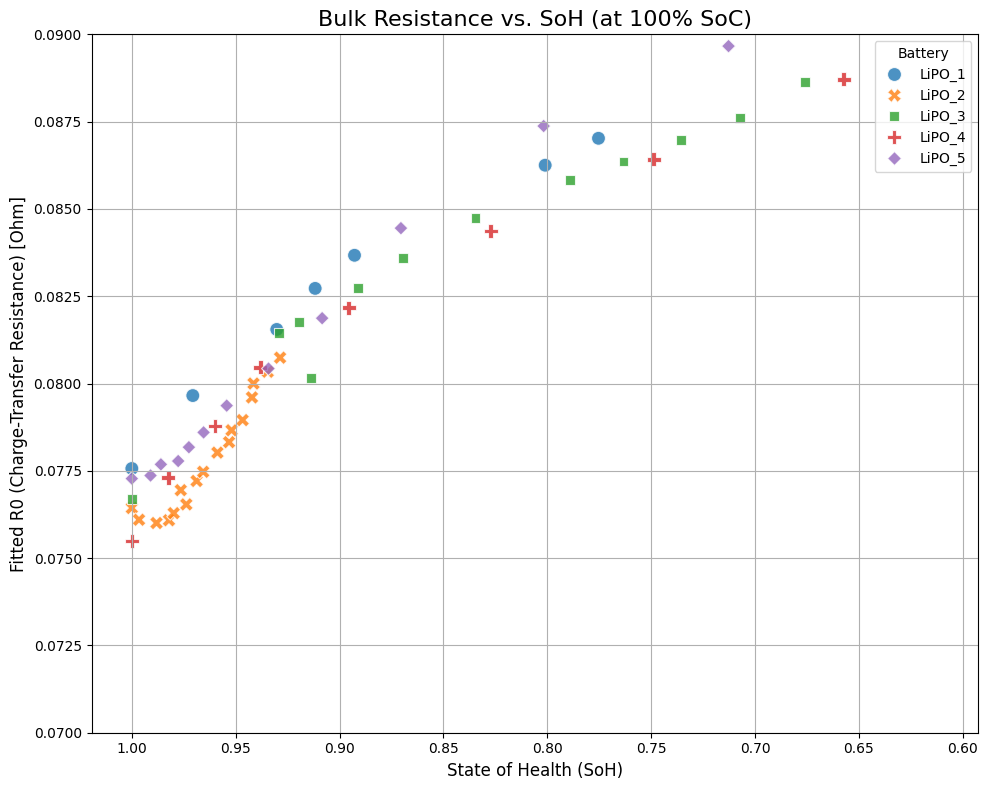

In [ ]:
target_soc = [0.5,0.1,1.0]  
r_ct_column = 'R0' 


for soc in target_soc:
    plot_data = all_battery_data_EIS[
    (all_battery_data_EIS["Modified SoC"] == soc) &
    (all_battery_data_EIS[r_ct_column].notna())
]
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        data=plot_data,
        x='SoH',
        y=r_ct_column,
        hue='Battery',  # This groups the data by battery
        style='Battery', # This gives each battery a different marker
        s=100,          # Adjust size of markers
        alpha=0.8,
        ax=ax
    )

    # --- 4. Customize the plot --- # SoH from 100% to 80%
    ax.set_ylim(bottom=0.07,top=0.09)  # Rct should be non-negative
    ax.set_title(f'Bulk Resistance vs. SoH (at {soc*100:.0f}% SoC)', fontsize=16)
    ax.set_xlabel('State of Health (SoH)', fontsize=12)
    ax.set_ylabel(f'Fitted {r_ct_column} (Charge-Transfer Resistance) [Ohm]', fontsize=12)

    # Invert X-axis to show 100% -> 80%
    ax.invert_xaxis() 

    ax.grid(True)
    ax.legend(title='Battery')

    plt.tight_layout()
    plt.show()

/var/folders/tf/yj0t6lyd7dz7mpbkbq4_c1rw0000gn/T/ipykernel_29094/2971714408.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = plot_data[~(all_battery_data_EIS[r_ct_column]>=0.7)]


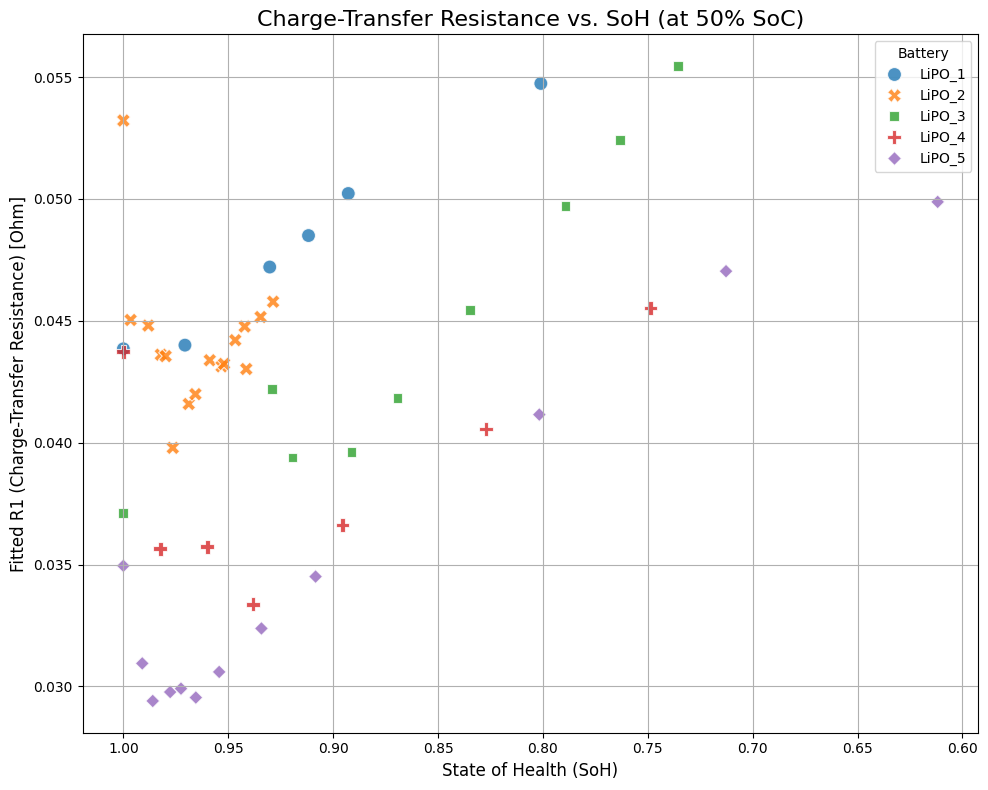

/var/folders/tf/yj0t6lyd7dz7mpbkbq4_c1rw0000gn/T/ipykernel_29094/2971714408.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = plot_data[~(all_battery_data_EIS[r_ct_column]>=0.7)]


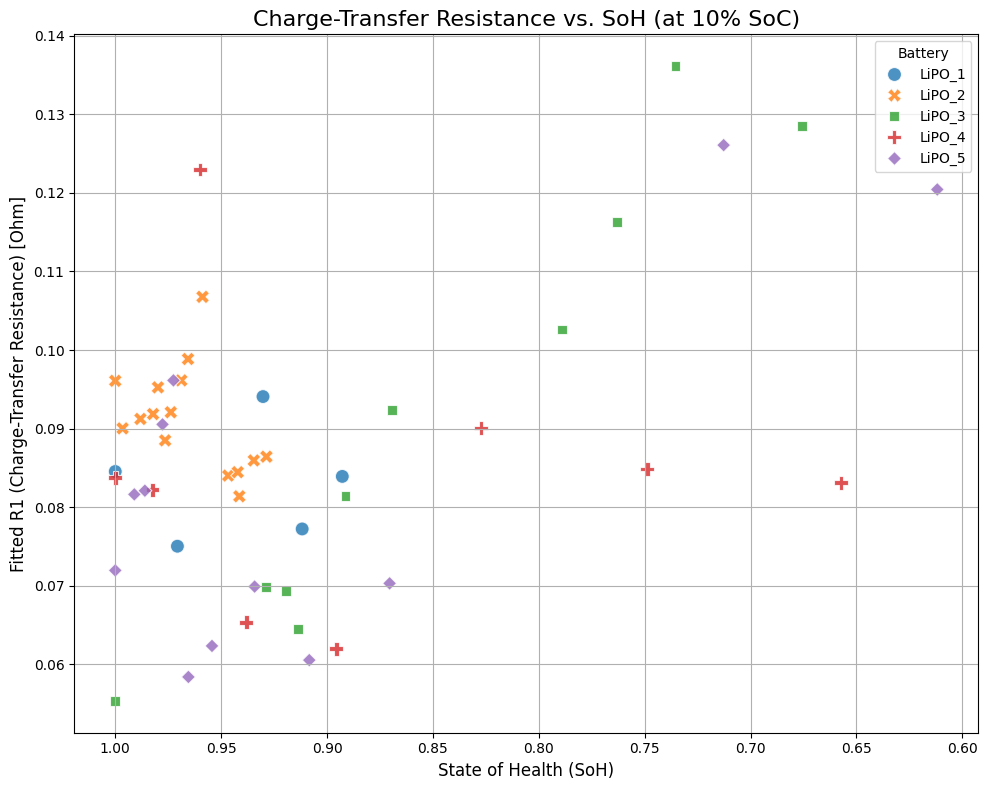

/var/folders/tf/yj0t6lyd7dz7mpbkbq4_c1rw0000gn/T/ipykernel_29094/2971714408.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = plot_data[~(all_battery_data_EIS[r_ct_column]>=0.7)]


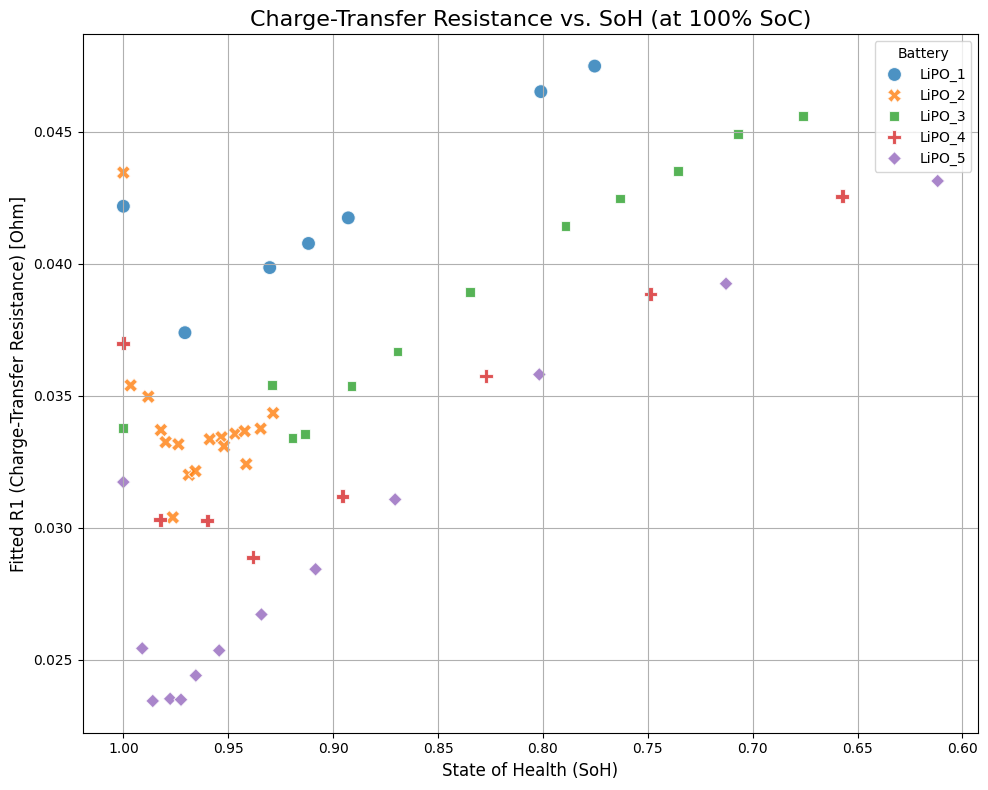

In [27]:
# --- 1. Define your target SoC and parameter ---
target_soc = [0.5,0.1,1.0]  # Set this to the SoC you want to analyze
r_ct_column = 'R1' # <-- IMPORTANT: Change this if your Rct column is named differently

# --- 2. Filter the DataFrame ---
# We select data for the target SoC and where the Rct is not null (fit was successful)


# --- 3. Create the 2D scatter plot ---
for soc in target_soc:
    plot_data = all_battery_data_EIS[
    (all_battery_data_EIS["Modified SoC"] == soc) &
    (all_battery_data_EIS[r_ct_column].notna())
]
    plot_data = plot_data[~(all_battery_data_EIS[r_ct_column]>=0.7)]
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        data=plot_data,
        x='SoH',
        y=r_ct_column,
        hue='Battery',  # This groups the data by battery
        style='Battery', # This gives each battery a different marker
        s=100,          # Adjust size of markers
        alpha=0.8,
        ax=ax
    )

    # --- 4. Customize the plot --- # SoH from 100% to 80%
    # ax.set_ylim(bottom=0.07,top=0.09)  # Rct should be non-negative
    ax.set_title(f'Charge-Transfer Resistance vs. SoH (at {soc*100:.0f}% SoC)', fontsize=16)
    ax.set_xlabel('State of Health (SoH)', fontsize=12)
    ax.set_ylabel(f'Fitted {r_ct_column} (Charge-Transfer Resistance) [Ohm]', fontsize=12)

    # Invert X-axis to show 100% -> 80%
    ax.invert_xaxis() 

    ax.grid(True)
    ax.legend(title='Battery')

    plt.tight_layout()
    plt.show()

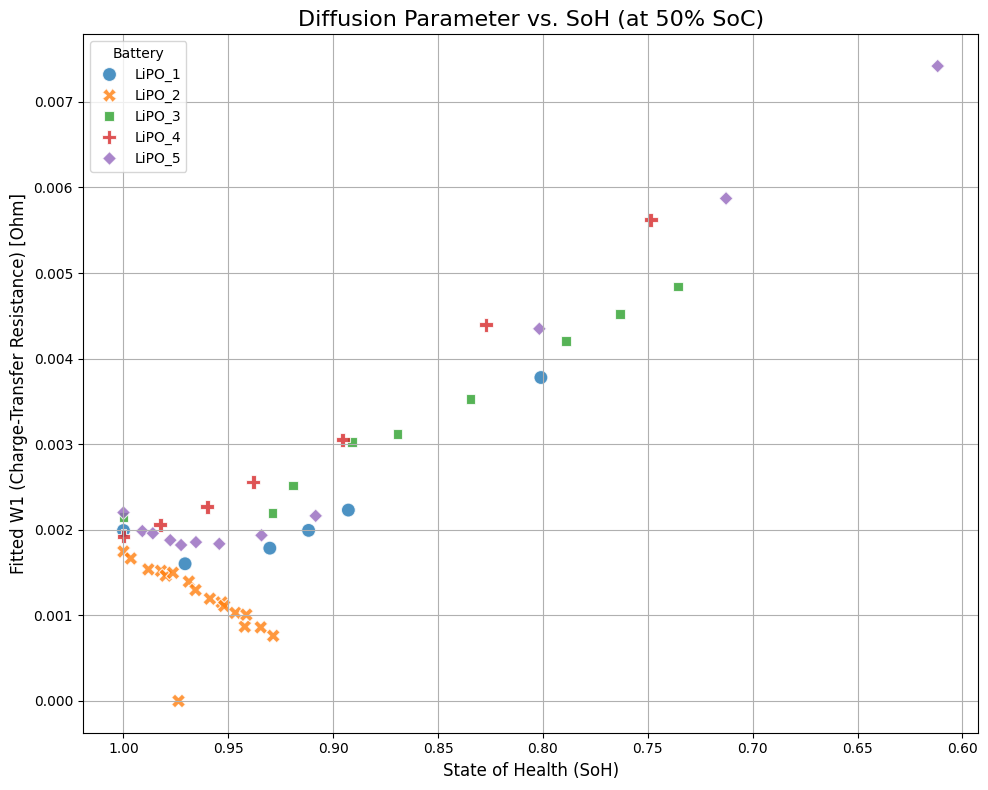

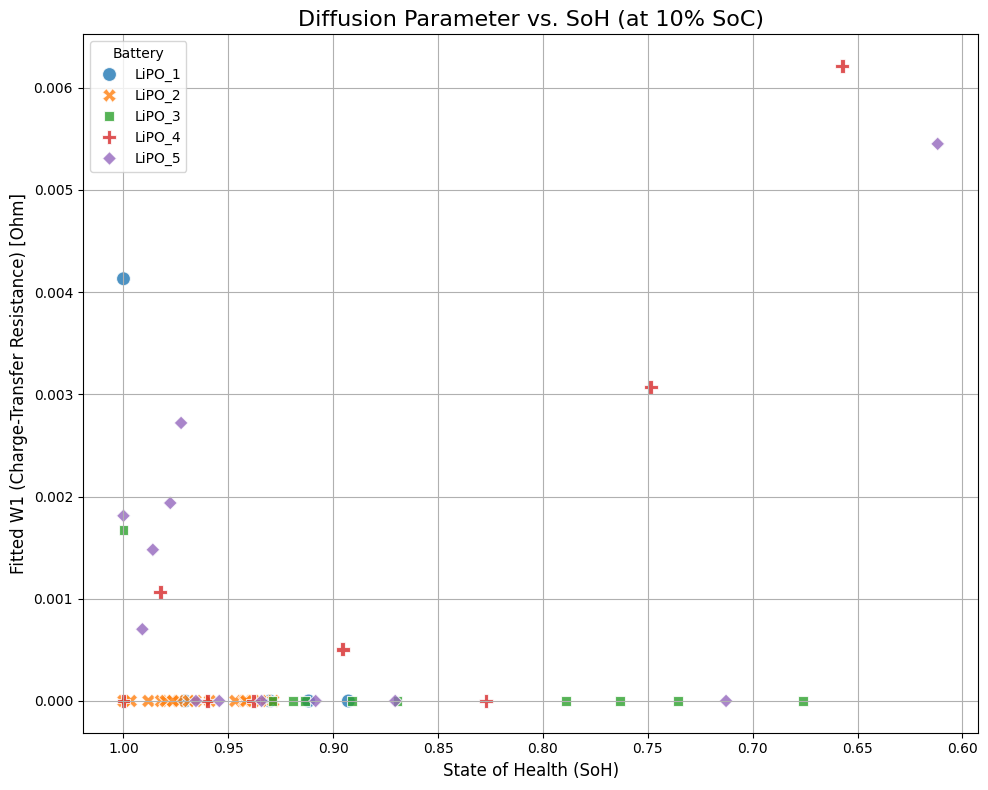

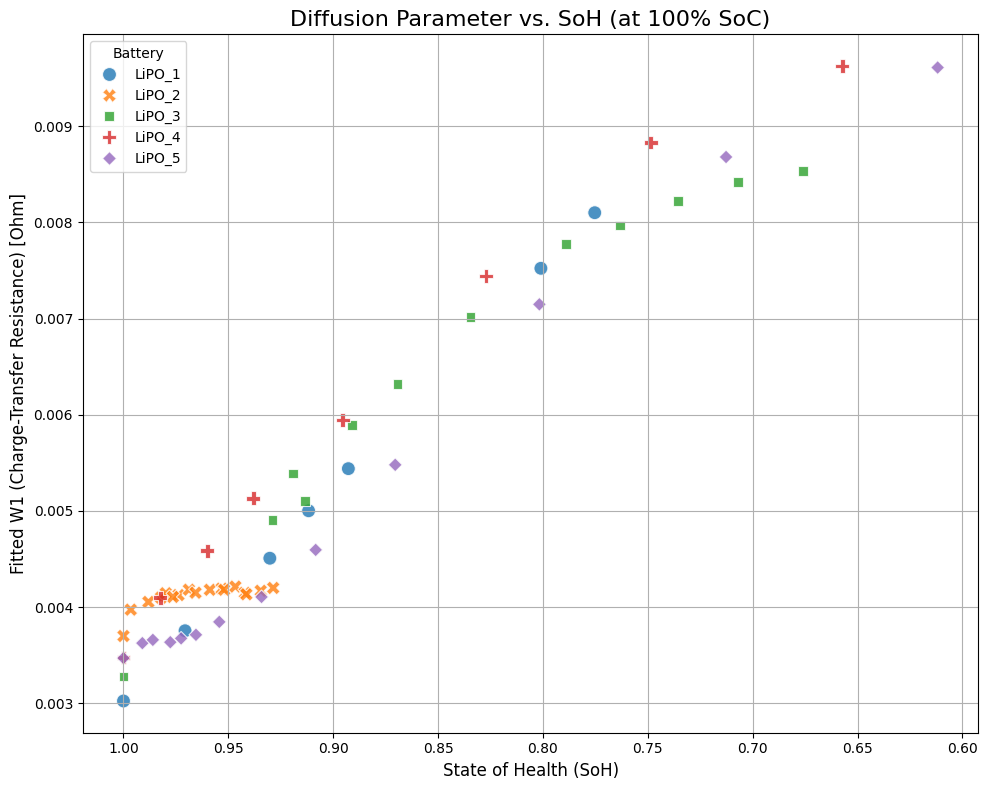

In [30]:
# --- 1. Define your target SoC and parameter ---
target_soc = [0.5,0.1,1.0]  # Set this to the SoC you want to analyze
r_ct_column = 'W1' # <-- IMPORTANT: Change this if your Rct column is named differently

# --- 2. Filter the DataFrame ---
# We select data for the target SoC and where the Rct is not null (fit was successful)


# --- 3. Create the 2D scatter plot ---
for soc in target_soc:
    plot_data = all_battery_data_EIS[
    (all_battery_data_EIS["Modified SoC"] == soc) &
    (all_battery_data_EIS[r_ct_column].notna())
]
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        data=plot_data,
        x='SoH',
        y=r_ct_column,
        hue='Battery',  # This groups the data by battery
        style='Battery', # This gives each battery a different marker
        s=100,          # Adjust size of markers
        alpha=0.8,
        ax=ax
    )

    # --- 4. Customize the plot --- # SoH from 100% to 80%
    # ax.set_ylim(bottom=0.07,top=0.09)  # Rct should be non-negative
    ax.set_title(f'Diffusion Parameter vs. SoH (at {soc*100:.0f}% SoC)', fontsize=16)
    ax.set_xlabel('State of Health (SoH)', fontsize=12)
    ax.set_ylabel(f'Fitted {r_ct_column} (Charge-Transfer Resistance) [Ohm]', fontsize=12)

    # Invert X-axis to show 100% -> 80%
    ax.invert_xaxis() 

    ax.grid(True)
    ax.legend(title='Battery')

    plt.tight_layout()
    plt.show()

# % Change Analysis in ECM Parameters

In [40]:
df = all_battery_data_EIS 
output_dir = 'EIS_Fitting_Plots_pct_change_by_Battery'

# --- 2. IMPORTANT: Define your list of fitted parameters ---
# These MUST match the parameter column names in your all_battery_data_EIS DataFrame
# This example uses the parameters from 'L1-R0-p(R1,CPE1)-W1'
fitting_parameters = ['L1', 'R0', 'R1', 'CPE1_0', 'CPE1_1', 'W1']

# --- 3. Create the main output directory ---
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving percentage change plots to base directory: {os.path.abspath(output_dir)}")

# --- 4. NEW: Outer loop for each battery ---
for battery in df['Battery'].unique():
    
    # --- 5. Create a specific sub-folder for this battery ---
    battery_folder_path = os.path.join(output_dir, str(battery))
    if not os.path.exists(battery_folder_path):
        os.makedirs(battery_folder_path)
    
    print(f"  -> Processing Battery: {battery}, saving in: {battery_folder_path}")
    
    # Filter the DataFrame for only this battery
    battery_data = df[df['Battery'] == battery]

    # --- 6. Loop through each parameter (as before) ---
    for param in fitting_parameters:
        plt.figure(figsize=(10, 6))
        
        # --- 7. Loop through each unique SoC ---
        for soc in battery_data['Modified SoC'].unique():
            
            # Filter data for this SoC and sort by Cycle
            soc_data = battery_data[battery_data['Modified SoC'] == soc].sort_values('Cycle')
            
            # Calculate % change
            pct_change = soc_data[param].pct_change() * 100
            
            # --- Plot the FILTERED data. plt.plot automatically skips NaN values ---
            plt.plot(soc_data['Cycle'], pct_change, marker='o', linestyle='-', label=f'SoC {soc*100:.0f}%')
            plt.ylim(-50, 100)  # Set y-axis limits to focus on relevant range
            
        plt.xlabel('Cycle Number', fontsize=14, fontweight='bold')
        plt.ylabel(f'% Change in {param}', fontsize=14, fontweight='bold')
        
        # --- Add Battery name to the title ---
        plt.title(f'Percentage Change in {param} for {battery}\n(All SoC values, Outliers Removed)', fontsize=16, fontweight='bold')
        
        plt.grid(True)
        plt.legend(fontsize=12)
        plt.tight_layout()
        
        # --- Save the plot to the battery-specific sub-folder ---
        plot_filename = os.path.join(battery_folder_path, f"{param}_pct_change_vs_Cycle.png")
        plt.savefig(plot_filename)
        plt.close() # Close the figure to save memory

print("\nAll percentage change plots have been saved.")

Saving percentage change plots to base directory: /Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/EIS_Fitting_Plots_pct_change_by_Battery
  -> Processing Battery: LiPO_1, saving in: EIS_Fitting_Plots_pct_change_by_Battery/LiPO_1
  -> Processing Battery: LiPO_2, saving in: EIS_Fitting_Plots_pct_change_by_Battery/LiPO_2
  -> Processing Battery: LiPO_3, saving in: EIS_Fitting_Plots_pct_change_by_Battery/LiPO_3
  -> Processing Battery: LiPO_4, saving in: EIS_Fitting_Plots_pct_change_by_Battery/LiPO_4
  -> Processing Battery: LiPO_5, saving in: EIS_Fitting_Plots_pct_change_by_Battery/LiPO_5

All percentage change plots have been saved.
